In [1]:
using DrWatson
@quickactivate "project"

using DifferentialEquations
using SimpleDiffEq
using Tables
using DataFrames
using StatsPlots
using LaTeXStrings # Для красивого отображения формул на графиках
using Plots
using BenchmarkTools

script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

function sir_ode!(du, u, p, t)
	(S, I, R) = u
	(β, c, γ) = p
	N = S + I + R
	@inbounds begin
		du[1] =-β * c * I / N * S
		du[2] = β * c * I / N * S- γ * I
		du[3] = γ * I
	end
	nothing
end

Precompiling packages...
   1046.6 ms  ✓ BenchmarkTools
  1 dependency successfully precompiled in 1 seconds. 16 already precompiled.


sir_ode! (generic function with 1 method)

Параметры модели

In [2]:
δt = 0.1
tmax = 40.0
tspan = (0.0, tmax)
u0 = [990.0, 10.0, 0.0] # S, I, R
p = [0.05, 10.0, 0.25] # β, c, γ

3-element Vector{Float64}:
  0.05
 10.0
  0.25

Расчет базового репродуктивного числа

In [3]:
R0 = (p[2] * p[1]) / p[3] # R0 = (c * β) / γ

2.0

Создание и решение задачи

In [4]:
prob_ode = ODEProblem(sir_ode!, u0, tspan, p)
sol_ode = solve(prob_ode, dt = δt)

retcode: Success
Interpolation: 3rd order Hermite
t: 15-element Vector{Float64}:
  0.0
  0.1
  0.5331242537191838
  1.3919008491040001
  2.6102120755226386
  4.1811820758323055
  6.180123810566044
  8.664951930903612
 11.691425331813486
 15.279370667110317
 19.082963490744028
 23.423425193442526
 28.42949373098617
 33.298779173639595
 40.0
u: 15-element Vector{Vector{Float64}}:
 [990.0, 10.0, 0.0]
 [989.4990153200853, 10.247898072276143, 0.25308660763853125]
 [987.1852964117763, 11.391111426852984, 1.4235921613706284]
 [981.8312125227972, 14.026022042698546, 4.14276543450428]
 [972.1392310589528, 18.757815561654187, 9.102953379393007]
 [954.9905500491583, 27.007702518267607, 18.00174743257403]
 [923.0706717929863, 41.92976779832721, 34.999560408686385]
 [862.6705810342164, 68.49345419063417, 68.83596477514932]
 [754.3022993851442, 109.74186185409279, 135.9558387607629]
 [595.1014268847736, 150.41363264480682, 254.48494047041947]
 [442.0141179101299, 154.80694988491865, 403.178932204951

Подготовка данных в DataFrame

In [5]:
df_ode = DataFrame(Tables.table(sol_ode'))
rename!(df_ode, ["S", "I", "R"])
df_ode[!, :t] = sol_ode.t
df_ode[!, :N] = df_ode.S + df_ode.I + df_ode.R # Общая численность популяции

15-element Vector{Float64}:
 1000.0
 1000.0
  999.9999999999999
 1000.0
 1000.0
  999.9999999999999
 1000.0
  999.9999999999999
 1000.0
  999.9999999999999
  999.9999999999998
 1000.0
 1000.0
 1000.0
 1000.0

Вывод параметров модели

In [6]:
println("Параметры модели SIR:")
println("β (вероятность заражения) = ", p[1])
println("c (среднее число контактов) = ", p[2])
println("γ (скорость выздоровления) = ", p[3])
println("R0 = c * β / γ = ", round(R0, digits=3))
println("Средняя продолжительность болезни = ", round(1/p[3], digits=2), " дней")
println("Начальные условия: S0 = ", u0[1], ", I0 = ", u0[2], ", R0 =", u0[3])

Параметры модели SIR:
β (вероятность заражения) = 0.05
c (среднее число контактов) = 10.0
γ (скорость выздоровления) = 0.25
R0 = c * β / γ = 2.0
Средняя продолжительность болезни = 4.0 дней
Начальные условия: S0 = 990.0, I0 = 10.0, R0 =0.0


1. ОСНОВНОЙ ГРАФИК: динамика всех трех групп

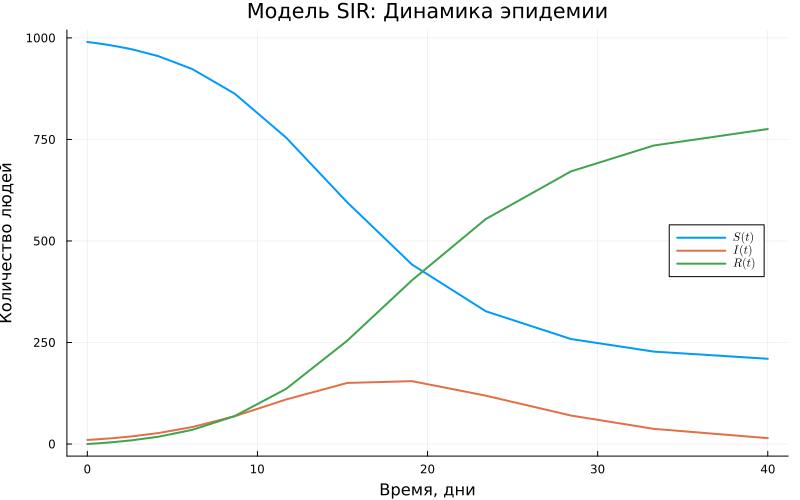

In [7]:
plt1 = @df df_ode plot(:t,
	[:S :I :R],
	label=[L"S(t)" L"I(t)" L"R(t)"],
	xlabel="Время, дни",
	ylabel="Количество людей",
	title="Модель SIR: Динамика эпидемии",
	linewidth=2,
	legend=:right,
	grid=true,
	size=(800, 500))

Добавление аннотаций с параметрами

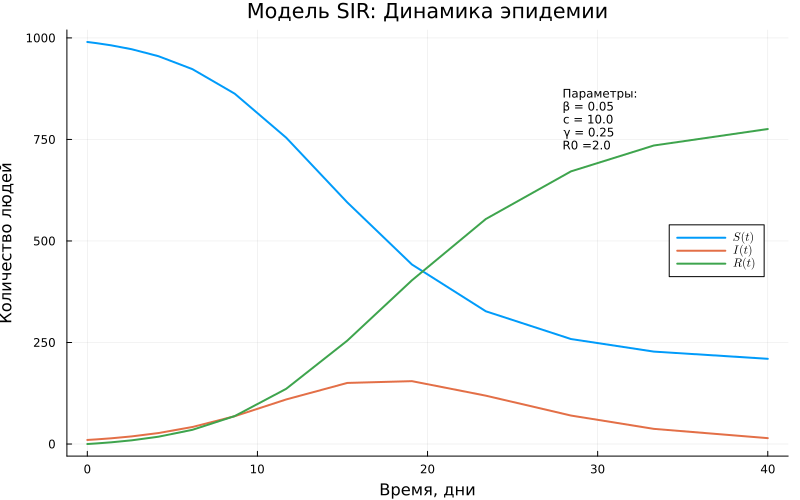

In [8]:
annotate!(plt1, maximum(df_ode.t) * 0.7, maximum(df_ode.N) * 0.8,
	text("Параметры:\nβ = $(p[1])\nc = $(p[2])\nγ = $(p[3])\nR0 =$(round(R0, digits=2))", 8, :left))

График только инфицированных (I)

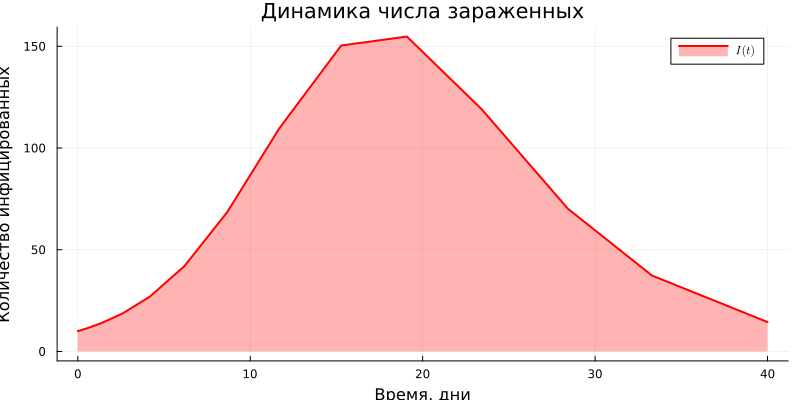

In [9]:
plt2 = @df df_ode plot(:t, :I,
	label=L"I(t)",
	xlabel="Время, дни",
	ylabel="Количество инфицированных",
	title="Динамика числа зараженных",
	color=:red,
	linewidth=2,
	fill=(0, 0.3, :red),
	grid=true,
	size=(800, 400))

Отметка пика эпидемии

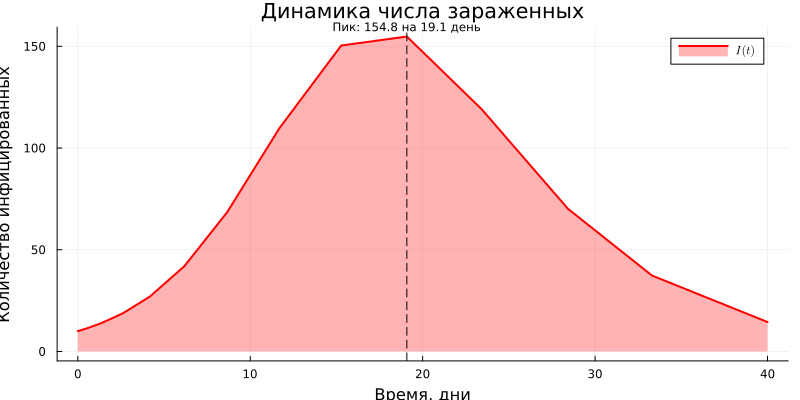

In [10]:
peak_idx = argmax(df_ode.I)
peak_time = df_ode.t[peak_idx]
peak_value = df_ode.I[peak_idx]
vline!(plt2, [peak_time], color=:black, linestyle=:dash, label=false, linewidth=1)
annotate!(plt2, peak_time, peak_value * 1.05,
	text("Пик: $(round(peak_value, digits=1)) на $(round(peak_time, digits=1)) день", 8, :top))

График в логарифмическом масштабе (для анализа экспоненциального роста)

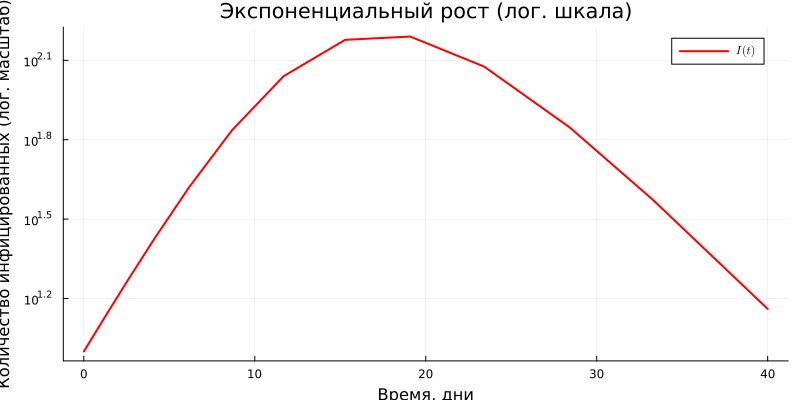

In [11]:
plt3 = @df df_ode plot(:t, :I,
	label=L"I(t)",
	xlabel="Время, дни",
	ylabel="Количество инфицированных (лог. масштаб)",
	title="Экспоненциальный рост (лог. шкала)",
	yscale=:log10,
	color=:red,
	linewidth=2,
	grid=true,
	size=(800, 400))

График долей населения (в процентах)

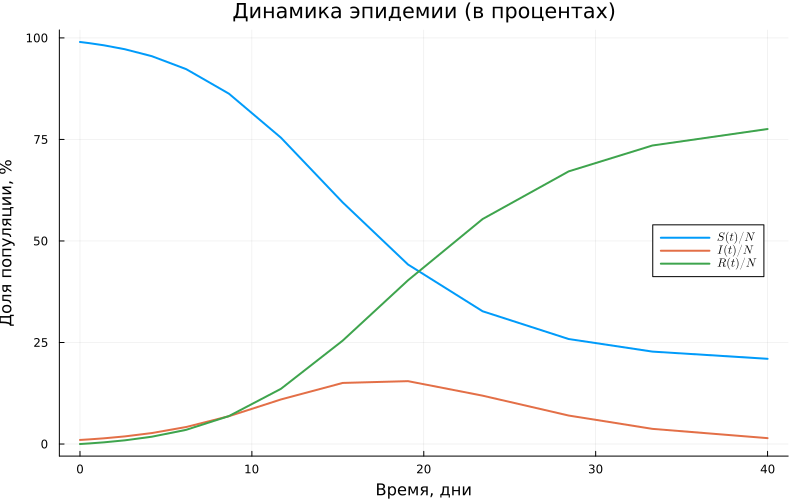

In [12]:
plt4 = @df df_ode plot(:t,
	[:S :I :R] ./ df_ode.N .* 100,
	label=[L"S(t)/N" L"I(t)/N" L"R(t)/N"],
	xlabel="Время, дни",
	ylabel="Доля популяции, %",
	title="Динамика эпидемии (в процентах)",
	linewidth=2,
	legend=:right,
	grid=true,
	size=(800, 500))

Горизонтальная линия для порога коллективного иммунитета

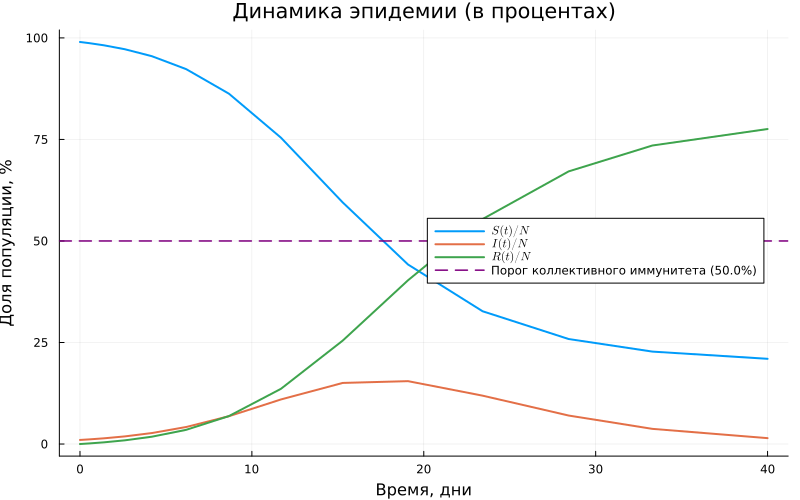

In [13]:
if R0 > 1
	herd_immunity_threshold = (1- 1/R0) * 100
	hline!(plt4, [herd_immunity_threshold], color=:purple, linestyle=:dash,
		label="Порог коллективного иммунитета ($(round(herd_immunity_threshold, digits=1))%)", linewidth=1.5)
end

Фазовый портрет (I vs S)

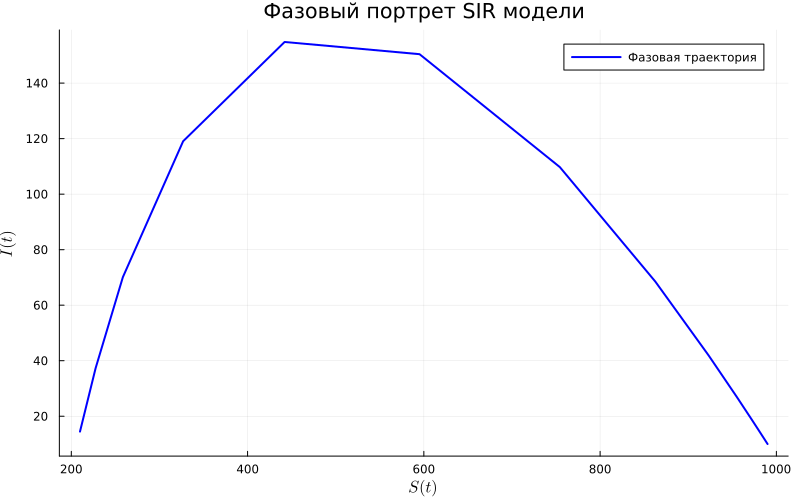

In [14]:
plt5 = plot(df_ode.S, df_ode.I,
	label="Фазовая траектория",
	xlabel=L"S(t)",
	ylabel=L"I(t)",
	title="Фазовый портрет SIR модели",
	color=:blue,
	linewidth=2,
	grid=true,
	size=(800, 500),
	legend=:topright)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*